In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import datetime as dt   
import matplotlib.pyplot as plt
import norgatedata

import talib
from tqdm import tqdm


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from alpha.engine.indicators import dv2_indicator

Past dv2 on Jan-21st 2022: 2.4%

🧠 Takeaway: "Rare" ≠ "Low Frequency"
Even though 2.4% is low rank-wise, it can still be frequent if the detrended oscillator often produces values in that bottom 5%.

That’s why:
The percentile rank says: “It’s low compared to the past.”
The histogram says: “This low range actually occurs often.”
So 2.4% is both “statistically low” and yet “historically common.” This is not a contradiction — it just means the asset frequently enters what the model calls an "oversold" regime.

✅ Final Summary
2.4% means: The current reading is in the bottom 2.4% of the past 126 days — an extreme reading by the indicator.
Histogram bar is high: Because AAPL tends to visit this “oversold” zone often, possibly due to its mean-reverting behavior or sharp dips.
If you're using dv2 as a contrarian indicator, this means you’re in one of the most historically reversion-prone conditions — but you'll want to check forward returns to confirm the edge.




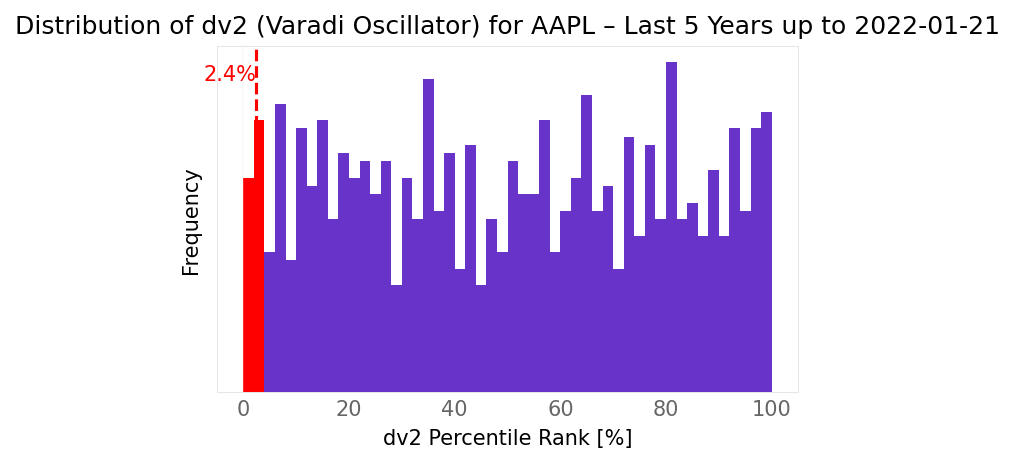

In [13]:
# histogram of daily returns
df = norgatedata.price_timeseries(
    'AAPL',
    stock_price_adjustment_setting=norgatedata.StockPriceAdjustmentType.CAPITALSPECIAL,
    timeseriesformat='pandas-dataframe'
)[['Open', 'High', 'Low', 'Close', 'Turnover']]

# Compute past 3-days returns
df['dv2'] = dv2_indicator(close=df['Close'], high=df['High'], low=df['Low'])
# Compute return after 5 days
df['5d_fwd_return'] = df['Close'].shift(-5) / df['Open'].shift(-1) - 1


# Filter the data for the past 5 years up to 2022-01-21
cutoff_date = np.datetime64('2022-01-21')
df = df.loc[df.index <= cutoff_date].tail(252 * 5)


data = df['dv2']

x = data.iloc[-1]
color1, color2 = '#6833C9', 'red'

fig, ax = plt.subplots(figsize=(5, 3), dpi=150)
# counts, bins, patches = ax.hist(data, bins=50)
counts, bins, patches = ax.hist(data, bins=np.linspace(0, 100, 51))


for spine in ax.spines.values():
    spine.set_edgecolor('#E6E6E6')
    spine.set_linewidth(0.5)

for i in range(len(bins) - 1):
    if bins[i] <= x:
        plt.setp(patches[i], 'facecolor', color2)
    else:
        plt.setp(patches[i], 'facecolor', color1)

ax.axvline(x=x, color='red', linestyle='--')
ax.axvline(x=0, color='#E6E6E6', linestyle='-', linewidth=0.2)

ax.tick_params(axis='both', which='both', length=0)
ax.tick_params(axis='x', colors='#666666')
ax.tick_params(axis='y', colors='#666666')
ax.set_yticklabels([]);
ax.text(x, ax.get_ylim()[1]*0.9, f'{x:.1f}%', color='red', ha='right')


plt.title('Distribution of dv2 (Varadi Oscillator) for AAPL – Last 5 Years up to 2022-01-21')
plt.xlabel('dv2 Percentile Rank [%]')
plt.ylabel('Frequency');

print(f"Past dv2 on Jan-21st 2022: {x:.1f}%")
s = """
🧠 Takeaway: "Rare" ≠ "Low Frequency"
Even though 2.4% is low rank-wise, it can still be frequent if the detrended oscillator often produces values in that bottom 5%.

That’s why:
The percentile rank says: “It’s low compared to the past.”
The histogram says: “This low range actually occurs often.”
So 2.4% is both “statistically low” and yet “historically common.” This is not a contradiction — it just means the asset frequently enters what the model calls an "oversold" regime.

✅ Final Summary
2.4% means: The current reading is in the bottom 2.4% of the past 126 days — an extreme reading by the indicator.
Histogram bar is high: Because AAPL tends to visit this “oversold” zone often, possibly due to its mean-reverting behavior or sharp dips.
If you're using dv2 as a contrarian indicator, this means you’re in one of the most historically reversion-prone conditions — but you'll want to check forward returns to confirm the edge.

"""
print(s)


In [7]:
df

,Open,High,Low,Close,Turnover,dv2,5d_fwd_return
Date,,,,,,,
1990-01-02,0.314732,0.334821,0.312500,0.332589,6.092982e+07,NaN,-0.009868
1990-01-03,0.339285,0.339285,0.334821,0.334821,6.964125e+07,NaN,-0.058824
1990-01-04,0.341518,0.345982,0.332589,0.335937,7.441473e+07,NaN,-0.086093
1990-01-05,0.337053,0.341518,0.330357,0.337053,4.156275e+07,NaN,-0.080000
1990-01-08,0.334821,0.339285,0.330357,0.339285,3.446220e+07,NaN,-0.098684
...,...,...,...,...,...,...,...
2025-05-19,207.910004,209.479996,204.259995,208.779999,9.577294e+09,74.603175,NaN
2025-05-20,207.669998,208.470001,205.029999,206.860001,8.796799e+09,74.603175,NaN
2025-05-21,205.169998,207.039993,200.710007,202.089996,1.204357e+10,17.460317,NaN


In [42]:
# calc feature for symbol
def get_events_from_symbol(
        symbol,
        fwd_return_window=5,
        start_date='1998-01-01'
):
    df = norgatedata.price_timeseries(
        symbol,
        stock_price_adjustment_setting=norgatedata.StockPriceAdjustmentType.CAPITALSPECIAL,
        start_date=start_date,
        timeseriesformat='pandas-dataframe',
    )[['Open', 'High', 'Low', 'Close', 'Turnover']]
    if len(df) == 0:
        return None
        
    df['symbol'] = symbol
    df['p126d_return'] = df['Close'] / df['Close'].shift(126) - 1
    df['natr'] = talib.NATR(df['High'], df['Low'], df['Close'], timeperiod=14)
    df['dv2'] = dv2_indicator(df['Close'], df['High'], df['Low'])
    df['sma_200'] = df['Close'].rolling(window=200).mean()
    df['next_open'] = df['Open'].shift(-1)
    df['return'] = df['Close'].shift(-fwd_return_window) / df['next_open'] - 1
    return df

In [43]:
# apply to all symbols in the S&P 500
symbols = norgatedata.watchlist_symbols('S&P 500 Current & Past')

results = []
for symbol in tqdm(symbols):
    res = get_events_from_symbol(symbol)
    if res is not None:
        results.append(res)

data = pd.concat(results)

events = data[
    (data['dv2'] < 10)
    & (data['p126d_return'] > 0)
    & (data['Close'] > data['sma_200'])
]

non_events = data[
    (data['dv2'] > 10)
    & (data['p126d_return'] > 0)
    & (data['Close'] > data['sma_200'])
]

events

100%|██████████| 1275/1275 [03:57<00:00,  5.38it/s]


,Open,High,Low,Close,Turnover,symbol,p126d_return,natr,dv2,sma_200,next_open,return
Date,,,,,,,,,,,,
2002-02-28,21.560656,21.621296,20.920572,20.987951,85706112.0,A,0.180819,4.410386,9.523810,19.032837,21.190083,0.106518
2002-03-20,24.255737,24.457869,23.110327,23.150755,134416320.0,A,0.581224,3.968223,2.380952,18.913647,23.177706,-0.033430
2002-03-25,23.204655,23.474163,22.436556,22.497196,58930012.0,A,0.657072,4.061615,3.174603,18.922743,22.638687,0.062500
2002-03-26,22.638687,23.177706,22.416344,22.584787,89535272.0,A,0.596190,3.997668,3.968254,18.922810,22.840820,0.033923
2002-04-03,24.592623,24.895821,23.319197,23.615656,105584624.0,A,0.858431,4.208496,7.142857,18.931233,23.730198,-0.057922
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-21,196.000000,196.975006,193.899994,194.660004,413190848.0,ZTS,0.156144,1.964134,5.555556,175.614900,195.320007,0.010496
2024-01-17,191.990005,193.014999,189.710007,190.899994,320694592.0,ZTS,0.115852,1.865294,3.968254,178.129600,191.429993,-0.028000
2024-01-23,191.550003,191.940002,187.789993,188.100006,280578112.0,ZTS,0.013579,2.005936,7.936508,178.576400,188.809998,0.013876


In [44]:
# get positive negative events
def get_positive_negative_events(df, return_column='return'):
    # compute descriptive statistics
    all_stats = df[return_column].describe()
    pos_stats = df[df[return_column] >= 0][return_column].describe()
    neg_stats = df[df[return_column] < 0][return_column].describe()

    # multiply all rows (except count) by 100
    stats_to_percent = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
    all_stats[stats_to_percent] *= 100
    pos_stats[stats_to_percent] *= 100
    neg_stats[stats_to_percent] *= 100

    # create DataFrame
    t1 = pd.DataFrame()
    t1['All events'] = all_stats
    t1['Positive events'] = pos_stats
    t1['Negative events'] = neg_stats

    # convert entire DataFrame to object dtype to allow string assignment
    t1 = t1.astype('object')

    # format all non-count rows with % strings
    for idx in t1.index:
        if idx != 'count':
            for col in t1.columns:
                val = t1.loc[idx, col]
                if pd.notna(val):
                    t1.loc[idx, col] = f"{val:.2f}%"

    # add percentage of total counts as formatted strings
    percentage_row = {
        'All events': "100.0%",
        'Positive events': f"{(pos_stats['count'] / all_stats['count']) * 100:.1f}%",
        'Negative events': f"{(neg_stats['count'] / all_stats['count']) * 100:.1f}%"
    }

    # finalize
    index = t1.index.tolist()
    rows = t1.to_dict('records')
    rows.insert(1, percentage_row)
    index.insert(1, '%')

    return pd.DataFrame(rows, index=index)
    
get_positive_negative_events(events, return_column='return')

,All events,Positive events,Negative events
count,239354.0,133369.0,105985.0
%,100.0%,55.7%,44.3%
mean,0.51%,3.52%,-3.28%
std,5.15%,4.13%,3.54%
min,-85.91%,0.00%,-85.91%
25%,-1.89%,1.15%,-4.36%
50%,0.46%,2.49%,-2.27%
75%,2.82%,4.56%,-1.01%
max,295.99%,295.99%,-0.00%


What we are seeing here ?

For S&P 500 Current & Past:
1. We have 239K of events.
2. The expectancy return is +0.51%.
3. Winrate is around 55.4%.
4. Each positive return event gets us 3.52% while negative yielded us -3.28%

For Nasdaq 100 Current:
1. We have 239K of events.
2. The expectancy return is +0.71%.
3. Winrate is around 55.4%.
4. Each positive return event gets us 4.50% while negative yielded us -4.0%

For Russell 2000 Current & Past:
1. We have 912K of events.
2. The expectancy return is +1.13%.
3. Winrate is around 54.0%.
4. Each positive return event gets us 6.35% while negative yielded us -5%

In [45]:
# let check if its an really edge
from scipy import stats

non_events = data[
    (data['dv2'] > 10)
    & (data['p126d_return'] > 0)
    & (data['Close'] > data['sma_200'])
]

# two sample welch t-test to compare the means of the two distributions
t_stat, p_value = stats.ttest_ind(
    events['return'].dropna(), 
    non_events['return'].dropna()
)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.2e}")

# Check the result
alpha = 0.05
if p_value < alpha:
    print("The means of the two distributions are significantly different.")
    print("We have an edge !")
else:
    print("The means of the two distributions are not significantly different.")
    print("We [dont] have an edge !")


T-statistic: 26.74
P-value: 1.56e-157
The means of the two distributions are significantly different.
We have an edge !


In [47]:
# ranking opportunities
# for short-term mean-reversion strategies, volatility is often a reliable ranking criterion..
# we will use the 14-day NATR

num_quantiles = 10

events['decile'] = pd.qcut(events['natr'], q=num_quantiles, labels=False)

res = []
for d in range(num_quantiles):
    data = events[events['decile'] == d]
    e = get_positive_negative_events(data)
    e.loc['%', 'All events'] = e.loc['%', 'Positive events']
    e = e.rename(index={'%': 'Win rate %'}, columns={'All events': d})
    res.append(e[d])

res = pd.concat(res, axis=1)
res

,0,1,2,3,4,5,6,7,8,9
count,23914.0,23938.0,23934.0,23937.0,23932.0,23934.0,23939.0,23941.0,23945.0,23940.0
Win rate %,55.2%,55.9%,55.7%,55.7%,55.6%,55.5%,55.8%,55.7%,55.5%,56.5%
mean,0.16%,0.28%,0.30%,0.34%,0.37%,0.44%,0.46%,0.54%,0.68%,1.53%
std,2.33%,2.83%,3.14%,3.40%,3.76%,4.16%,4.62%,5.27%,6.18%,10.48%
min,-27.61%,-29.37%,-37.61%,-21.61%,-32.96%,-42.37%,-29.35%,-62.20%,-40.92%,-85.91%
25%,-1.13%,-1.31%,-1.48%,-1.59%,-1.77%,-1.94%,-2.27%,-2.60%,-3.09%,-4.09%
50%,0.24%,0.33%,0.36%,0.40%,0.46%,0.49%,0.55%,0.62%,0.74%,1.19%
75%,1.53%,1.96%,2.19%,2.36%,2.63%,2.97%,3.28%,3.67%,4.37%,6.70%
max,26.09%,29.22%,33.14%,41.64%,39.06%,71.59%,46.12%,48.77%,51.30%,295.99%


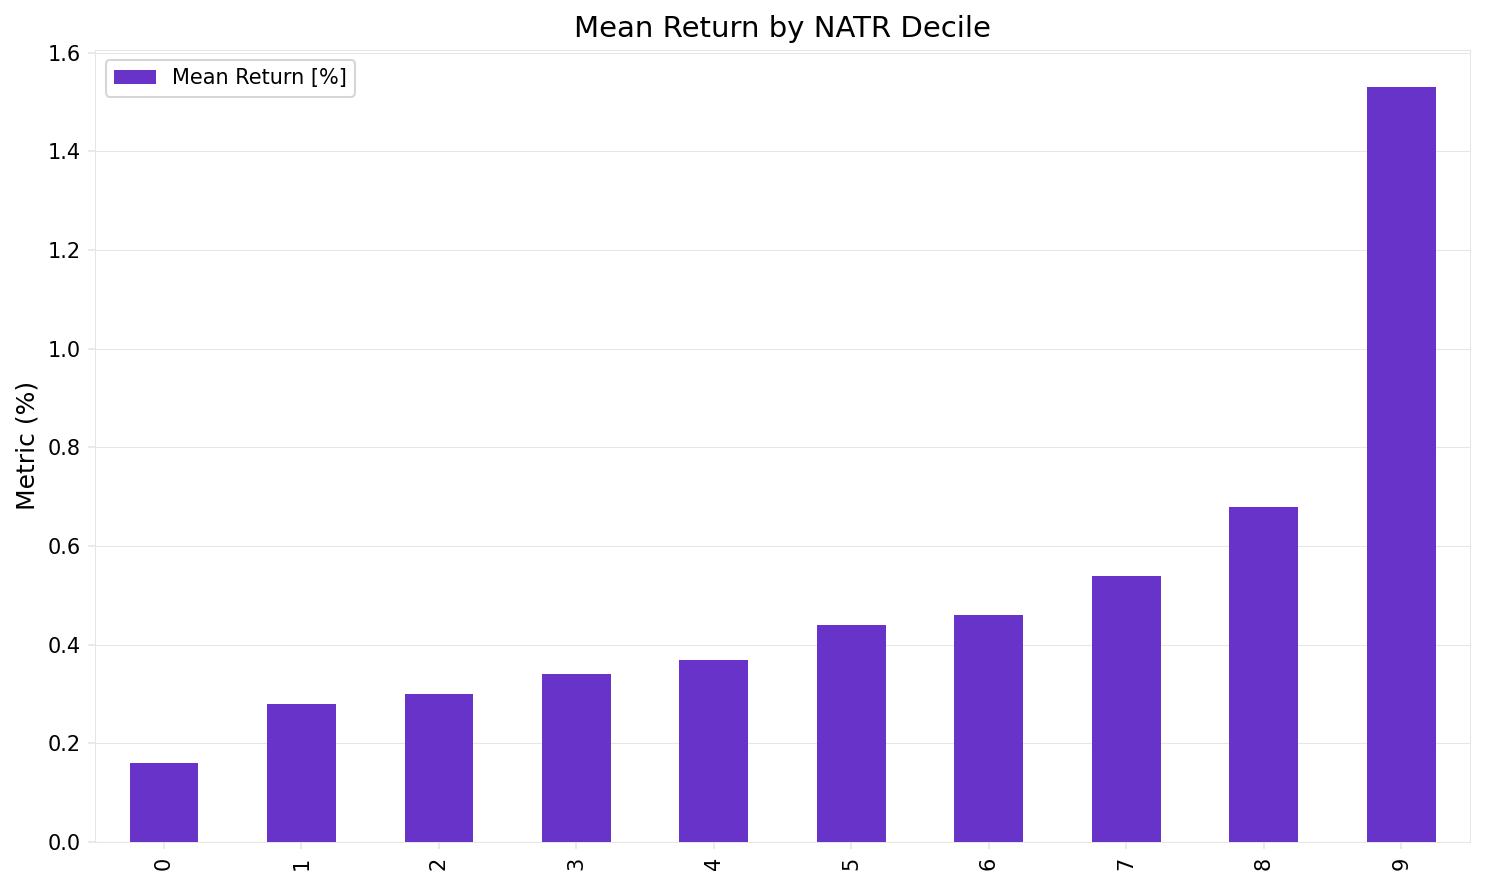

In [59]:

# extract and convert percentage strings to floats
mean_returns = res.loc['mean'].str.replace('%', '').astype(float)

# build DataFrame for plotting
xx = pd.DataFrame({
    'Mean Return [%]': mean_returns
}).T

# plot
fig, ax = plt.subplots(1, 1, dpi=150, figsize=(10, 6))
xx.T.plot(kind='bar', ax=ax, color=['#6833C9'], zorder=10)

# labels and title
ax.set_ylabel('Metric (%)', fontsize=12)
ax.set_title('Mean Return by NATR Decile', fontsize=14)

# apply styling
for spine in ax.spines.values():
    spine.set_edgecolor('#E6E6E6')
    spine.set_linewidth(0.5)

ax.tick_params(axis='x', colors="#000000", labelsize=10)
ax.tick_params(axis='y', colors='#000000', labelsize=10)
ax.tick_params(axis='y', which='both', color='#e6e6e6')
ax.tick_params(axis='x', which='both', color='#e6e6e6')
ax.grid(which='major', linestyle='-', linewidth='0.5', color='#e6e6e6', zorder=0, axis='y')

plt.tight_layout()
plt.show()


As expected, the **higher the volatility, the higher the expected return in these short-term mean-reversion trades**. Now, let's formulate a strategy to exploit this edge.

